In [13]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib.gridspec as gridspec
import glob
plt.rcParams.update({'font.size': 12})
plt.rcParams['font.family'] = 'sans-serif'
from scipy.ndimage import gaussian_filter


In [14]:
def smooth_2d_gaussian(Z, sigma=1):
    return gaussian_filter(Z, sigma=sigma)

[-10.   -9.5  -9.   -8.5  -8.   -7.5  -7.   -6.5  -6.   -5.5  -5.   -4.5
  -4.   -3.5  -3.   -2.5  -2.   -1.5  -1.   -0.5   0.    0.5   1.    1.5
   2.    2.5   3.    3.5   4.    4.5   5.    5.5   6.    6.5   7.    7.5
   8.    8.5   9.    9.5  10.   10.5  11.   11.5  12.   12.5  13.   13.5
  14.   14.5  15.   15.5  16.   16.5  17.   17.5  18.   18.5  19.   19.5]
[-20.  -19.5 -19.  -18.5 -18.  -17.5 -17.  -16.5 -16.  -15.5 -15.  -14.5
 -14.  -13.5 -13.  -12.5 -12.  -11.5 -11.  -10.5 -10.   -9.5  -9.   -8.5
  -8.   -7.5  -7.   -6.5  -6.   -5.5  -5.   -4.5  -4.   -3.5  -3.   -2.5
  -2.   -1.5  -1.   -0.5   0.    0.5   1.    1.5   2.    2.5   3.    3.5
   4.    4.5   5.    5.5   6.    6.5   7.    7.5   8.    8.5   9.    9.5
  10.   10.5  11.   11.5  12.   12.5  13.   13.5  14.   14.5  15.   15.5
  16.   16.5  17.   17.5  18.   18.5  19.   19.5]


<Figure size 640x480 with 0 Axes>

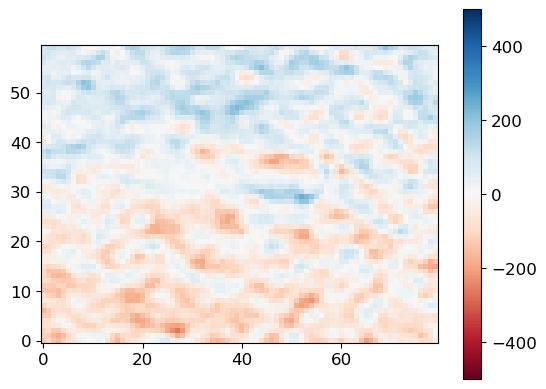

<Figure size 640x480 with 0 Axes>

In [15]:
files = sorted(glob.glob('/data/seismo/joshin/pipeline-test/local_correlation_tracking/pmi/ar_inflow/data/data_4k_to_be_stitched_test/*.hdf5'))
for k, file in enumerate(files):
    flow_data = h5py.File(file)
    if k==0:
        uphi = flow_data['uphi'][:]
        uthe = flow_data['utheta'][:]
        tstart = flow_data['tstart'][:]
        longitude = flow_data['longitude'][:]
        latitude = flow_data['latitude'][:]
    else:
        uphi = np.concatenate((uphi, flow_data['uphi'][:]), axis=0)
        uthe = np.concatenate((uthe, flow_data['utheta'][:]), axis=0)
        tstart = np.concatenate((tstart, flow_data['tstart'][:]), axis=0)

print(latitude)
print(longitude)
uphi_mean = np.nanmean(uphi, axis=0)
uthe_mean = np.nanmean(uthe, axis=0)
plt.figure()
plt.imshow(uthe_mean, cmap='RdBu', origin='lower', vmax=500, vmin=-500)
plt.colorbar()
plt.figure()

In [16]:
print(uphi.shape)

(192, 60, 80)


In [17]:
def fit_poly_along_x(Z, degree=2):
    """
    Fit a polynomial along each row (x-axis direction) of the 2D array.
    Returns a 2D array of the fitted values.
    """
    ny, nx = Z.shape
    X = np.arange(nx)
    Z_fit = np.zeros_like(Z)

    for j in range(ny):
        coeffs = np.polyfit(X, Z[j, :], degree)
        poly = np.poly1d(coeffs)
        Z_fit[j, :] = poly(X)

    return Z_fit

def fit_poly_along_y(Z, degree=2):
    """
    Fit a polynomial along each column (y-axis direction) of the 2D array.
    Returns a 2D array of the fitted values.
    """
    ny, nx = Z.shape
    Y = np.arange(ny)
    Z_fit = np.zeros_like(Z)

    for i in range(nx):
        coeffs = np.polyfit(Y, Z[:, i], degree)
        poly = np.poly1d(coeffs)
        Z_fit[:, i] = poly(Y)

    return Z_fit


In [18]:
# Fit just along x

uphi_for_quiver = np.nanmean(uphi, axis=0)
uthe_for_quiver = np.nanmean(uthe, axis=0)
Zx_fit = fit_poly_along_x(uphi_mean, degree=1)

# Fit just along y
Zy_fit = fit_poly_along_y(uthe_mean, degree=1)

# Optional: remove background (one direction)
Zx_corrected = uphi_for_quiver - Zx_fit
Zy_corrected = uthe_for_quiver - Zy_fit


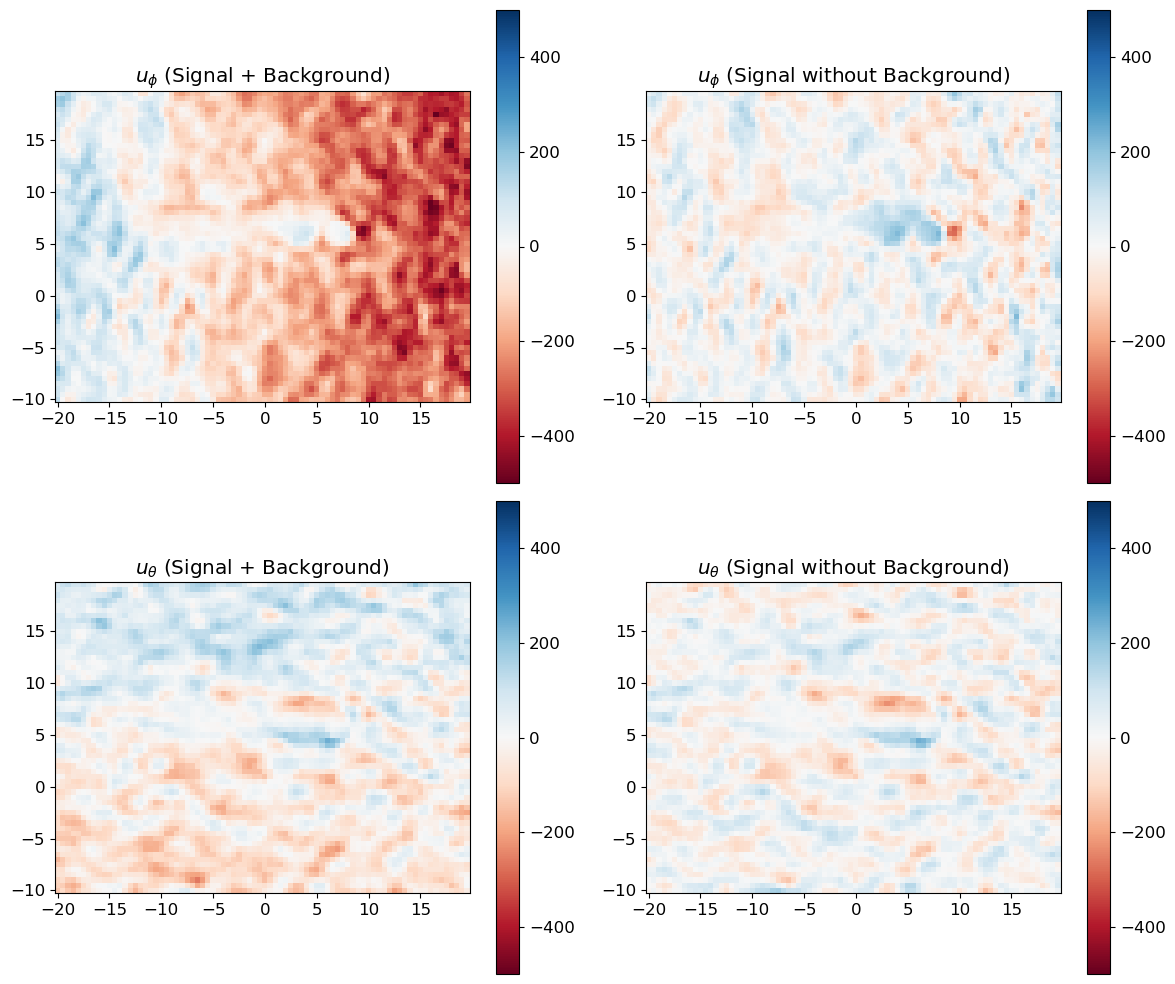

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

im0 = axs[0, 0].pcolormesh(longitude, latitude, uphi_for_quiver, cmap='RdBu', vmin=-500, vmax=500)
# im0 = axs[0, 0].imshow(uphi_for_quiver, cmap='RdBu', origin='lower', vmax=500, vmin=-500)
axs[0, 0].set_aspect('equal')
axs[0, 0].set_title(r'$u_\phi$ (Signal + Background)')
plt.colorbar(im0, ax=axs[0, 0])

im1 = axs[0, 1].pcolormesh(longitude, latitude, Zx_corrected, cmap='RdBu', vmin=-500, vmax=500)
# im1 = axs[0, 1].imshow(Zx_corrected, cmap='RdBu', origin='lower', vmax=500, vmin=-500)
axs[0, 1].set_aspect('equal')
axs[0, 1].set_title(r'$u_\phi$ (Signal without Background)')
plt.colorbar(im1, ax=axs[0, 1])

im2 = axs[1, 0].pcolormesh(longitude, latitude, uthe_for_quiver, cmap='RdBu', vmin=-500, vmax=500)
# im2 = axs[1, 0].imshow(uthe_for_quiver, cmap = 'RdBu', origin='lower', vmax=500, vmin=-500)
axs[1, 0].set_aspect('equal')
axs[1, 0].set_title(r'$u_\theta$ (Signal + Background)')
plt.colorbar(im2, ax=axs[1, 0])

im3 = axs[1, 1].pcolormesh(longitude, latitude, Zy_corrected, cmap='RdBu', vmin=-500, vmax=500)
axs[1, 1].set_aspect('equal')
# im3 = axs[1, 1].imshow(Zy_corrected, cmap='RdBu', origin='lower', vmax=500, vmin=-500)
axs[1, 1].set_title(r'$u_\theta$ (Signal without Background)')
plt.colorbar(im3, ax=axs[1, 1])

plt.tight_layout()
# plt.savefig('flow_background_removal_4k.pdf')
plt.show()

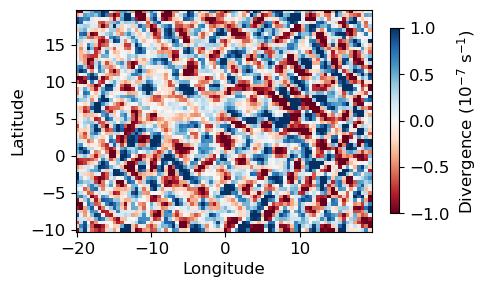

In [20]:
hdiv = np.gradient(Zx_corrected, axis = 0) + np.gradient(-Zy_corrected, axis = 1)
rsun = 6.96e8
hdiv = hdiv /rsun
fig1, ax1 = plt.subplots(figsize=(5, 5))
im = ax1.pcolormesh(longitude, latitude, hdiv*1e7, cmap='RdBu', vmin=-1, vmax=1)
fig1.colorbar(im, ax=ax1, label=r'Divergence ($10^{-7}$ s$^{-1}$)', shrink=0.4)
ax1.set_aspect('equal')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
fig1.tight_layout()


In [21]:
sigma = 2
smooth_hdiv = smooth_2d_gaussian(hdiv, sigma=sigma)
smooth_zx_corrected = smooth_2d_gaussian(Zx_corrected, sigma=sigma)
smooth_zy_corrected = smooth_2d_gaussian(Zy_corrected, sigma=sigma)

# smooth_hdiv = hdiv
# smooth_zx_corrected = Zx_corrected
# smooth_zy_corrected = Zy_corrected


/tmp/ipykernel_71346/1523957335.py:8: UserWarning: linewidths is ignored by contourf
  CS = ax.contourf(


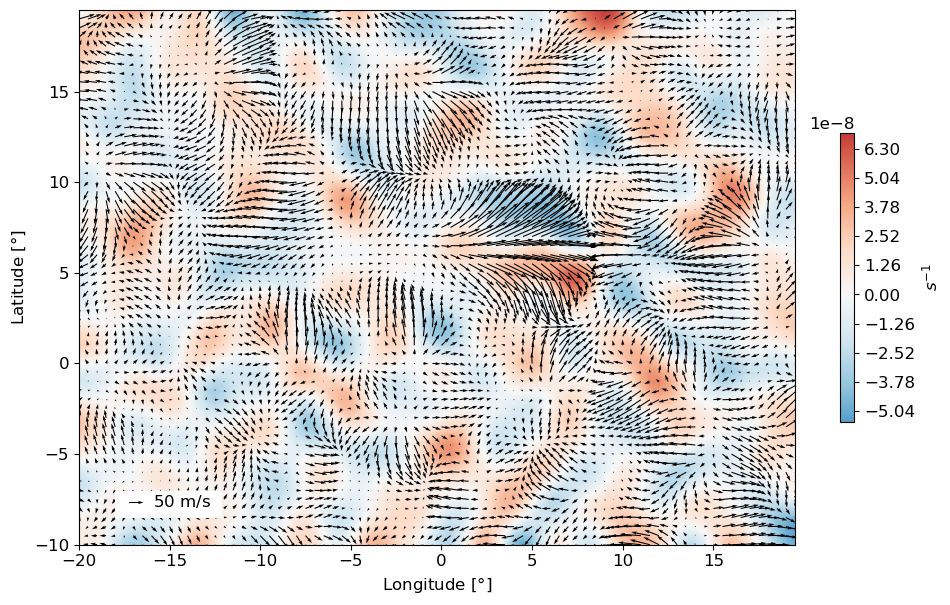

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# --- Contour plot (set lower zorder to make sure quiver key is on top) ---
CS = ax.contourf(
    longitude, latitude, smooth_hdiv,
    levels=1000, linewidths=1, cmap = 'RdBu_r',
    vmin=-1e-7, vmax=1e-7,
    zorder=1  # Lower than quiver key
)

# --- Quiver plot (set appropriate scale and position for arrows) ---
Q = ax.quiver(
    longitude, latitude,
    smooth_zx_corrected, -smooth_zy_corrected,
    scale=2500,  # Adjust to match your vector magnitudes
    width=0.0015, color = 'black', zorder=2
)

# --- Add white background for quiver key ---
# --- Add white background for quiver key ---
ax.add_patch(Rectangle(
    (0.05, 0.05),  # (x, y) in axes coords (bottom-left corner)
    0.15, 0.05,     # width, height in axes coords
    transform=ax.transAxes,
    facecolor='white',
    edgecolor='none',
    zorder=2  # Ensure this is above contours and arrows
))

# --- Add quiver key (label for 500 m/s) ---
qk = ax.quiverkey(
    Q, X=0.09, Y=0.08, U=50,
    label=r'$50\ \mathrm{m/s}$',
    labelpos='E',
    coordinates='axes',
    color='black',
    labelcolor='black',
    zorder=4  # Ensure this is above all other elements
)

# --- Optional: round background for the text label ---
# qk.text.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))

# --- Labels and formatting ---
ax.set_aspect('equal')
ax.set_xlabel(r'Longitude [$\degree$]')
ax.set_ylabel(r'Latitude [$\degree$]')


# --- Apply padding so labels + key don't get cut off ---
plt.tight_layout(rect=[0, 0, 1, 1])  # prevents overlap
fig.colorbar(CS, ax=ax, orientation='vertical', label=r'$s^{-1}$', shrink = 0.3)
# --- Save the figure ---
# fig.savefig("ar_flow_quiver_hdiv_smooth_2k_030_test.pdf", bbox_inches='tight')

# --- Show the plot (if you're testing interactively) ---
# plt.show()

In [11]:
np.savez('/data/seismo/joshin/pipeline-test/local_correlation_tracking/pmi/ar_inflow/data/data_cleaned/smooth_data_4k_30.npz', smooth_zx_corrected=smooth_zx_corrected, smooth_zy_corrected=smooth_zy_corrected, smooth_hdiv=smooth_hdiv, longitude=longitude, latitude=latitude)

36905


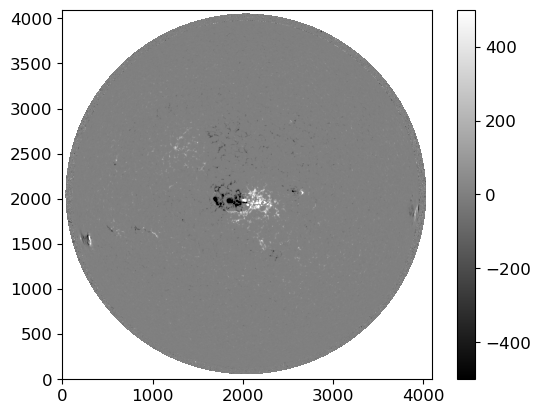

In [23]:
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
keys = Table.read('/scratch/seismo/joshin/pipeline-test/IterativeLCT/hmi.m_720s/keys_new_swan/keys-2015.fits')
# find the indx of row with date 2015-11-01
idx = np.where(keys['t_rec'] == '2015.11.04_12:00:00_TAI')[0][0]
# row = keys['t_rec'] == '2015.11.01_00:00:00_TAI'
print(idx)
img_path = keys['path'][idx][:-1] + '/magnetogram.fits'
img = fits.getdata(img_path)
plt.figure()
plt.imshow(img, cmap='gray', vmin=-500, vmax=500, origin='lower')
plt.colorbar()

In [24]:
import sys
sys.path.insert(0, '/data/seismo/zhichao/codes/pypkg')
from zclpy3.remap import rot_tan_map, from_tan_to_cyl
ncyl = 2000
nx_out = ny_out = 2000
wcs_cyl  = WCS(naxis=2)
wcs_cyl.wcs.ctype = 'longitude', 'latitude'
wcs_cyl.wcs.cunit = 'deg', 'deg'
wcs_cyl.wcs.crpix = 0.5*(1+ncyl), 0.5*(1+ncyl)
wcs_cyl.wcs.crval = 0, 0
wcs_cyl.wcs.cdelt = 0.09, 0.09
dL = 0
dB = keys['crlt_obs'][idx]
dP = -keys['crota2'][idx]
interp_method = 'bilinear'
verbose = 1
nthr = 1
crpix1, crpix2 = keys['crpix1'][idx], keys['crpix2'][idx]
crval1, crval2 = keys['crval1'][idx], keys['crval2'][idx]
cdelt1, cdelt2 = keys['cdelt1'][idx], keys['cdelt2'][idx]
rsun_obs = keys['rsun_obs'][idx]
print('rsun_obs for cyl', rsun_obs)
img_no_blur_helio = from_tan_to_cyl(np.nan_to_num(img[np.newaxis, :, :]),
        crpix1, crpix2, crval1, crval2,
        cdelt1, cdelt2,
        rsun_obs, dB, dP, dL,
        nx_out, ny_out, wcs_cyl,
        interp_method, verbose, nthr, header=False)

rsun_obs for cyl 967.570557


In [25]:
# plot the remapped image
lng, = wcs_cyl.sub([1]).wcs_pix2world(range(ncyl), 0)
lat, = wcs_cyl.sub([2]).wcs_pix2world(range(ncyl), 0)
print(lng.min(), lng.max(), lat.min(), lat.max())

-89.955 89.955 -89.955 89.955


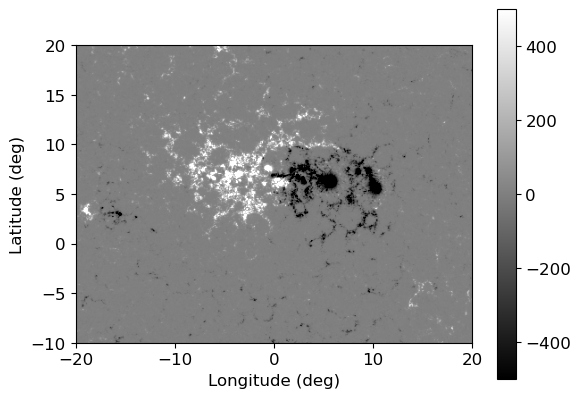

In [26]:
plt.figure()
plt.imshow(img_no_blur_helio[0, :, :], cmap='gray', vmin=-500, vmax=500, origin='lower',
           extent=[lng.min(), lng.max(), lat.min(), lat.max()])
plt.colorbar()
plt.xlabel('Longitude (deg)')
plt.ylabel('Latitude (deg)')
plt.xlim(-20, 20)
plt.ylim(-10, 20)
plt.show()


In [27]:
# find the indices corresponding to your display limits
lng_mask = (lng >= -20) & (lng <= 20)
lat_mask = (lat >= -10) & (lat <= 20)

# slice the image
img_cropped = img_no_blur_helio[0, lat_mask, :][:, lng_mask]
np.savez('/data/seismo/joshin/pipeline-test/local_correlation_tracking/pmi/ar_inflow/data/data_cleaned/magnetogram_cropped.npz', img_cropped=img_cropped, longitude=lng[lng_mask], latitude=lat[lat_mask])

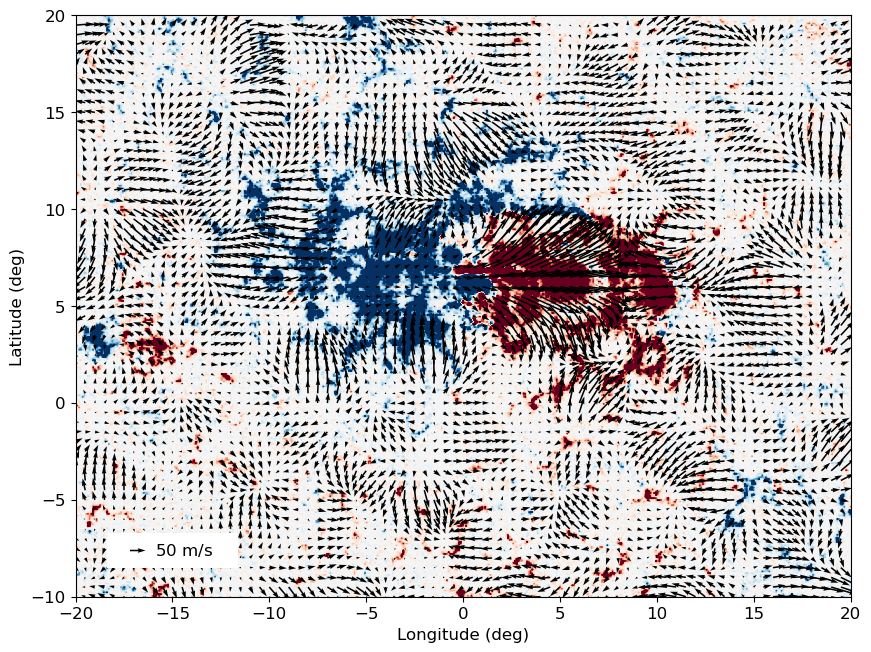

In [25]:
# Overlay the flow quiver on the magnetogram
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_no_blur_helio[0, :, :], cmap='RdBu', vmin=-100, vmax=100, origin='lower',
           extent=[lng.min(), lng.max(), lat.min(), lat.max()])
Q = ax.quiver(longitude, latitude,
                smooth_zx_corrected, -smooth_zy_corrected,
                scale=2500, width=0.0020, color='black')
ax.add_patch(Rectangle(
    (0.04, 0.05),  # (x, y) in axes coords (bottom-left corner)
    0.17, 0.06,     # width, height in axes coords
    transform=ax.transAxes,
    facecolor='white',
    edgecolor='none',
    zorder=1  # Ensure this is above contours and arrows
))
qk = ax.quiverkey(
    Q, X=0.09, Y=0.08, U=50,
    label=r'$50\ \mathrm{m/s}$',
    labelpos='E',
    coordinates='axes',
    color='black',
    labelcolor='black',
    zorder=4  # Ensure this is above all other elements
)

ax.set_xlim(-20, 20)
ax.set_ylim(-10, 20)
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
# plt.savefig('ar_flow_quiver_on_magnetogram_2k_015.pdf', bbox_inches='tight')
plt.show()
